# Анализ финансовой отчётности российских компаний
## RFSD (Russian Financial Statements Dataset)

---

**Цель:** Исследовательский анализ данных (EDA) финансовых показателей российских компаний

**Задачи:**
1. Загрузка и очистка данных
2. Описательная статистика
3. Визуализация распределений (гистограммы)
4. Анализ выбросов
5. Корреляционный анализ
6. Выявление интересных закономерностей

## 1. Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Настройка визуализации
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# Настройки pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✓ Библиотеки успешно импортированы")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

## 2. Загрузка данных

**Примечание:** Скачайте датасет RFSD из репозитория https://github.com/irlcode/RFSD  
Поместите файл в директорию `data/raw/`

In [ ]:
# Загрузка данных (сначала проверим структуру)
# ВАЖНО: Замените 'rfsd_full.csv' на реальное имя файла из репозитория

try:
    # Загружаем первые 5 строк для проверки
    # Используем pd.read_parquet для файлов .parquet
    df_sample = pd.read_parquet('../data/raw/part-0.parquet')
    df_sample = df_sample.head(5)
    print("✓ Датасет найден!")
    print(f"\nКолонки в датасете ({len(df_sample.columns)}):")
    print(df_sample.columns.tolist())
    print("\nПервые строки:")
    display(df_sample.head())
except FileNotFoundError:
    print("❌ Файл не найден!")
    print("Пожалуйста:")
    print("1. Скачайте датасет RFSD из https://github.com/irlcode/RFSD")
    print("2. Поместите файл в директорию data/raw/")
    print("3. Обновите имя файла в коде выше")
except ImportError:
    print("❌ Требуется установить pyarrow!")
    print("Выполните: pip install pyarrow")

In [13]:
# Загрузка полного датасета
df_full = pd.read_parquet('../data/raw/part-0.parquet')

print(f"Размер полного датасета: {df_full.shape}")
print(f"Строк: {df_full.shape[0]:,}")
print(f"Колонок: {df_full.shape[1]}")
print(f"\nПамять: {df_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Размер полного датасета: (3170560, 213)
Строк: 3,170,560
Колонок: 213

Память: 5627.03 MB


## 3. Первичный анализ структуры данных

In [14]:
# Информация о типах данных
print("=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===")
df_full.info()

=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===
<class 'pandas.DataFrame'>
RangeIndex: 3170560 entries, 0 to 3170559
Columns: 213 entries, inn to line_6400
dtypes: float64(196), object(2), str(15)
memory usage: 5.3+ GB


In [15]:
# Проверка пропущенных значений
missing_data = pd.DataFrame({
    'Колонка': df_full.columns,
    'Пропуски': df_full.isnull().sum(),
    'Процент': (df_full.isnull().sum() / len(df_full) * 100).round(2)
})
missing_data = missing_data[missing_data['Пропуски'] > 0].sort_values('Процент', ascending=False)

print("\n=== ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ===")
if len(missing_data) > 0:
    display(missing_data)
else:
    print("✓ Пропусков нет!")


=== ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ===


,Колонка,Пропуски,Процент
line_2450,line_2450,3170560,100.00
line_2421,line_2421,3170560,100.00
line_2430,line_2430,3170560,100.00
line_3501,line_3501,3170560,100.00
line_3500,line_3500,3170560,100.00
...,...,...,...
oktmo,oktmo,13158,0.42
okfc,okfc,5035,0.16
okopf,okopf,570,0.02
region_taxcode,region_taxcode,4,0.00


In [16]:
# Первые строки датасета
print("=== ПЕРВЫЕ 10 СТРОК ===")
display(df_full.head(10))

=== ПЕРВЫЕ 10 СТРОК ===


,inn,ogrn,region,region_taxcode,creation_date,dissolution_date,age,eligible,exemption_criteria,financial,filed,imputed,simplified,articulated,totals_adjustment,outlier,okved,okved_section,okpo,okopf,okogu,okfc,oktmo,lon,lat,geocoding_quality,line_1100,line_1110,line_1120,line_1130,line_1140,line_1150,line_1160,line_1170,line_1180,line_1190,line_1200,line_1210,line_1220,line_1230,line_1240,line_1250,line_1260,line_1300,line_1310,line_1320,line_1340,line_1350,line_1360,line_1370,line_1400,line_1410,line_1420,line_1430,line_1450,line_1500,line_1510,line_1520,line_1530,line_1540,line_1550,line_1600,line_1700,line_2100,line_2110,line_2120,line_2200,line_2210,line_2220,line_2300,line_2310,line_2320,line_2330,line_2340,line_2350,line_2400,line_2410,line_2411,line_2412,line_2421,line_2430,line_2450,line_2460,line_2500,line_2510,line_2520,line_2530,line_2900,line_2910,line_3100,line_3200,line_3210,line_3211,line_3212,line_3213,line_3214,line_3215,line_3216,line_321x,line_3220,line_3221,line_3222,line_3223,line_3224,line_3225,line_3226,line_3227,line_322x,line_3230,line_3240,line_3300,line_3310,line_3311,line_3312,line_3313,line_3314,line_3315,line_3316,line_331x,line_3320,line_3321,line_3322,line_3323,line_3324,line_3325,line_3326,line_3327,line_332x,line_3330,line_3340,line_3400,line_3401,line_3402,line_3410,line_3411,line_3412,line_3420,line_3421,line_3422,line_3500,line_3501,line_3502,line_3600,line_4100,line_4110,line_4111,line_4112,line_4113,line_4119,line_411x,line_4120,line_4121,line_4122,line_4123,line_4124,line_4129,line_412x,line_4200,line_4210,line_4211,line_4212,line_4213,line_4214,line_4219,line_421x,line_4220,line_4221,line_4222,line_4223,line_4224,line_4229,line_422x,line_4300,line_4310,line_4311,line_4312,line_4313,line_4314,line_4319,line_431x,line_4320,line_4321,line_4322,line_4323,line_4329,line_432x,line_4400,line_4450,line_4490,line_4500,line_6100,line_6200,line_6210,line_6215,line_6220,line_6230,line_6240,line_6250,line_6300,line_6310,line_6311,line_6312,line_6313,line_6320,line_6321,line_6322,line_6323,line_6324,line_6325,line_6326,line_6330,line_6350,line_6400
0,NaN,9047796688213,moscow city,7700,2004-09-15,None,20.00,1.00,none,0.00,0.00,0.00,NaN,NaN,NaN,0.00,46.21.14,G,NaN,12300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0100000011,1210100002353,adygeya,0100,2021-10-27,None,3.00,1.00,none,0.00,1.00,0.00,1.00,1.00,1.00,0.00,56.10,I,58800768,12300,4210014,16,79701000001,40.1006395,44.6087241,house,161.00,NaN,NaN,NaN,NaN,161.00,NaN,NaN,NaN,NaN,5097.00,3248.00,NaN,1486.00,NaN,363.00,NaN,3091.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,2167.00,214.00,1953.00,NaN,NaN,NaN,5258.00,5258.00,NaN,65475.00,-63460.00,2015.00,NaN,NaN,2015.00,NaN,NaN,NaN,NaN,NaN,39.00,-1976.00,NaN,NaN,NaN,NaN,NaN,NaN,39.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 4. Выбор 20 колонок

**Критерии отбора:**
- Финансовые показатели (выручка, прибыль, активы и т.д.)
- Метаданные (компания, год, отрасль)
- Расчетные коэффициенты (ROE, ROA, коэффициенты ликвидности)
- Минимум пропусков
- Числовые данные для анализа корреляций

In [17]:
# ВАЖНО: Адаптируйте этот список под реальные имена колонок в вашем датасете!
# Пример ожидаемых колонок:

selected_columns = [
    'inn',
    'ogrn',
    'region',
    'region_taxcode',
    'creation_date',
    'dissolution_date',
    'age',
    'eligible',
    'exemption_criteria',
    'financial',
    'line_1180',
    'line_1190',
    'line_1200',
    'line_1210',
    'totals_adjustment',
    'outlier',
    'okved',
    'okved_section',
    'okpo',
    'okopf'
]

# Проверка наличия колонок
available_columns = [col for col in selected_columns if col in df_full.columns]
missing_columns = [col for col in selected_columns if col not in df_full.columns]

print(f"✓ Доступных колонок: {len(available_columns)}/{len(selected_columns)}")
if missing_columns:
    print(f"\n❌ Отсутствующие колонки: {missing_columns}")
    print("\nПожалуйста, адаптируйте список selected_columns под реальные имена в датасете")
    print("\nДоступные колонки:")
    print(df_full.columns.tolist())

✓ Доступных колонок: 20/20


In [18]:
# Создание датасета с выбранными колонками
# После адаптации списка колонок, раскомментируйте:

df_selected = df_full[available_columns].copy()
print(f"Датасет с выбранными колонками: {df_selected.shape}")
display(df_selected.head())

Датасет с выбранными колонками: (3170560, 20)


,inn,ogrn,region,region_taxcode,creation_date,dissolution_date,age,eligible,exemption_criteria,financial,line_1180,line_1190,line_1200,line_1210,totals_adjustment,outlier,okved,okved_section,okpo,okopf
0,NaN,9047796688213,moscow city,7700,2004-09-15,None,20.00,1.00,none,0.00,NaN,NaN,NaN,NaN,NaN,0.00,46.21.14,G,NaN,12300
1,0100000011,1210100002353,adygeya,0100,2021-10-27,None,3.00,1.00,none,0.00,NaN,NaN,5097.00,3248.00,1.00,0.00,56.10,I,58800768,12300
2,0100000043,1210100002364,adygeya,0100,2021-10-29,None,3.00,1.00,none,0.00,NaN,NaN,10.00,NaN,1.00,0.00,94.99,S,74969343,20200
3,0100000068,1210100002375,adygeya,0100,2021-10-29,2024-12-24,3.00,1.00,none,0.00,NaN,NaN,NaN,NaN,NaN,0.00,68.32.20,L,NaN,12300
4,0100000075,1210100002386,adygeya,0100,2021-11-03,None,3.00,1.00,none,0.00,NaN,NaN,NaN,NaN,0.00,0.00,96.09,S,53637594,20200


## 5. Сокращение до 1000 строк

Используем стратифицированную выборку для репрезентативности

In [19]:
# Выбор метода сэмплирования
# Метод 1: Простая случайная выборка
df_sample = df_selected.sample(n=1000, random_state=42)

# Метод 2: Стратифицированная выборка по отраслям (рекомендуется)
# if 'industry' in df_selected.columns:
#     df_sample = df_selected.groupby('industry', group_keys=False).apply(
#         lambda x: x.sample(min(len(x), max(1, int(1000 * len(x) / len(df_selected)))), random_state=42)
#     ).head(1000)
# else:
#     df_sample = df_selected.sample(n=1000, random_state=42)

print(f"Итоговый датасет: {df_sample.shape}")
print(f"\nРаспределение по годам:")
if 'year' in df_sample.columns:
    print(df_sample['year'].value_counts().sort_index())

# print(f"\nРаспределение по отраслям:")
# if 'industry' in df_sample.columns:
#     print(df_sample['industry'].value_counts())

Итоговый датасет: (1000, 20)

Распределение по годам:


In [21]:
# Сохранение обработанного датасета
df_sample.to_csv('../data/processed/rfsd_1000x20.csv', index=False)
print("✓ Датасет сохранен в data/processed/rfsd_1000x20.csv")

✓ Датасет сохранен в data/processed/rfsd_1000x20.csv


## 6. Описательная статистика

In [22]:
# Описательная статистика для числовых переменных
print("=== ОПИСАТЕЛЬНАЯ СТАТИСТИКА ===")
description = df_sample.describe()
display(description)

# Транспонированная версия для лучшей читаемости
print("\n=== ТРАНСПОНИРОВАННАЯ ВЕРСИЯ ===")
display(description.T)

=== ОПИСАТЕЛЬНАЯ СТАТИСТИКА ===


,age,eligible,financial,line_1180,line_1190,line_1200,line_1210,totals_adjustment,outlier
count,1000.00,1000.00,1000.00,42.00,32.00,658.00,424.00,704.00,1000.00
mean,10.54,0.99,0.00,53003.93,16086.91,55039.38,24709.35,0.92,0.00
std,8.27,0.08,0.00,211075.62,48400.36,373448.22,225768.35,0.28,0.00
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4.00,1.00,0.00,0.00,0.00,169.75,15.75,1.00,0.00
50%,9.00,1.00,0.00,1944.50,0.00,3940.50,937.00,1.00,0.00
75%,16.00,1.00,0.00,14516.75,1333.25,20469.75,6057.75,1.00,0.00
max,60.00,1.00,0.00,1353809.00,237249.00,8547617.00,4515529.00,1.00,0.00



=== ТРАНСПОНИРОВАННАЯ ВЕРСИЯ ===


,count,mean,std,min,25%,50%,75%,max
age,1000.00,10.54,8.27,0.00,4.00,9.00,16.00,60.00
eligible,1000.00,0.99,0.08,0.00,1.00,1.00,1.00,1.00
financial,1000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
line_1180,42.00,53003.93,211075.62,0.00,0.00,1944.50,14516.75,1353809.00
line_1190,32.00,16086.91,48400.36,0.00,0.00,0.00,1333.25,237249.00
line_1200,658.00,55039.38,373448.22,0.00,169.75,3940.50,20469.75,8547617.00
line_1210,424.00,24709.35,225768.35,0.00,15.75,937.00,6057.75,4515529.00
totals_adjustment,704.00,0.92,0.28,0.00,1.00,1.00,1.00,1.00
outlier,1000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [23]:
# Дополнительная статистика
print("\n=== ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df_sample)}")
print(f"Количество колонок: {len(df_sample.columns)}")

# # Категориальные переменные
categorical_cols = df_sample.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    print("\n=== КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ ===")
    for col in categorical_cols:
        print(f"{col}: {df_sample[col].nunique()} уникальных значений")

# # Проверка пропущенных значений
print("\n=== ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ===")
missing = df_sample.isnull().sum()
if missing.sum() > 0:
    display(missing[missing > 0])
else:
    print("✓ Пропусков нет")


=== ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 1000
Количество колонок: 20

=== КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ ===
inn: 1000 уникальных значений
ogrn: 1000 уникальных значений
region: 84 уникальных значений
region_taxcode: 84 уникальных значений
creation_date: 918 уникальных значений
dissolution_date: 82 уникальных значений
exemption_criteria: 3 уникальных значений
okved: 361 уникальных значений
okved_section: 19 уникальных значений
okpo: 913 уникальных значений
okopf: 34 уникальных значений

=== ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ===


dissolution_date     873
line_1180            958
line_1190            968
line_1200            342
line_1210            576
totals_adjustment    296
okved                  4
okved_section          4
okpo                  87
dtype: int64

## 7. Гистограммы для 3 колонок

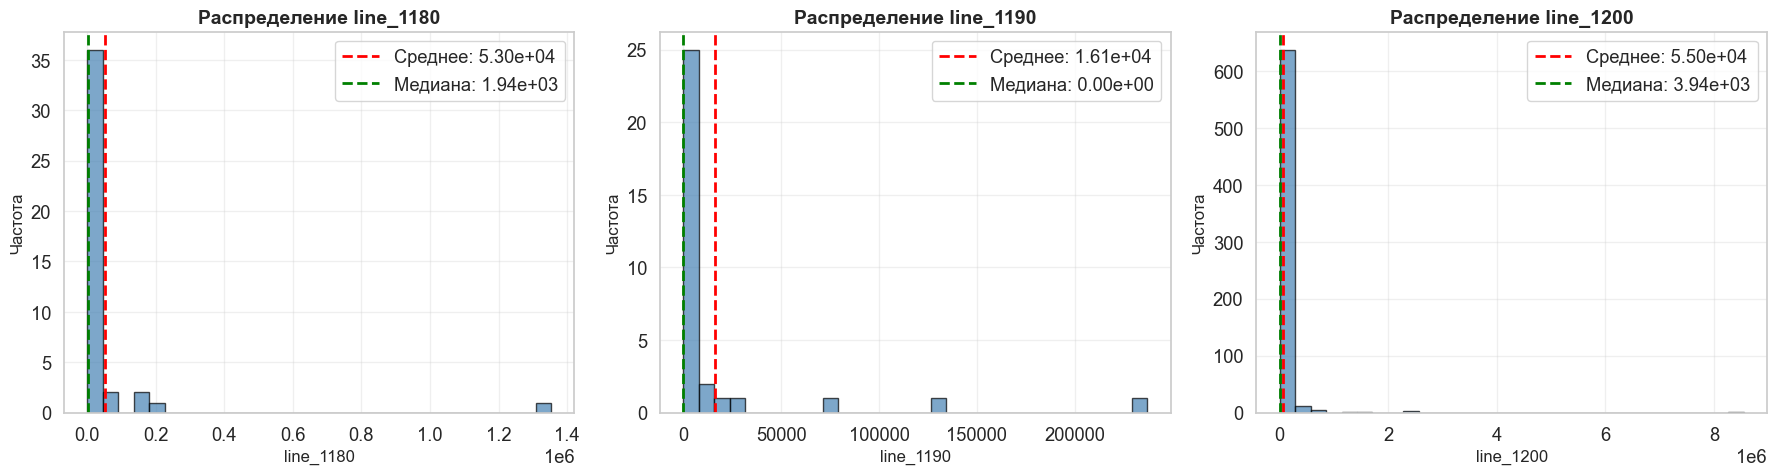

✓ Гистограммы построены и сохранены


In [24]:
# Выберите 3 наиболее интересные числовые колонки
columns_to_plot = ['line_1180', 'line_1190', 'line_1200']  # Адаптируйте под ваши данные 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(columns_to_plot):
    if col in df_sample.columns:
        data = df_sample[col].dropna()
        
        # Гистограмма
        axes[idx].hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_xlabel(col, fontsize=12)
        axes[idx].set_ylabel('Частота', fontsize=12)
        axes[idx].set_title(f'Распределение {col}', fontsize=14, fontweight='bold')
        
        # Добавление статистических линий
        mean_val = data.mean()
        median_val = data.median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2e}')
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_val:.2e}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/histograms/histograms_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Гистограммы построены и сохранены")

## 8. Анализ выбросов

In [26]:
# Функция для детектирования выбросов методом IQR
def detect_outliers_iqr(df, column):
    """
    Детектирование выбросов методом межквартильного размаха (IQR)
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"\n{'='*60}")
    print(f"ВЫБРОСЫ В КОЛОНКЕ: {column}")
    print(f"{'='*60}")
    print(f"Q1 (25%):           {Q1:.2f}")
    print(f"Q3 (75%):           {Q3:.2f}")
    print(f"IQR:                {IQR:.2f}")
    print(f"Нижняя граница:     {lower_bound:.2f}")
    print(f"Верхняя граница:    {upper_bound:.2f}")
    print(f"Количество выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    
    return outliers

# # Анализ выбросов для выбранных колонок
for col in columns_to_plot:
    if col in df_sample.columns:
        outliers = detect_outliers_iqr(df_sample, col)


ВЫБРОСЫ В КОЛОНКЕ: line_1180
Q1 (25%):           0.00
Q3 (75%):           14516.75
IQR:                14516.75
Нижняя граница:     -21775.12
Верхняя граница:    36291.88
Количество выбросов: 6 (0.60%)

ВЫБРОСЫ В КОЛОНКЕ: line_1190
Q1 (25%):           0.00
Q3 (75%):           1333.25
IQR:                1333.25
Нижняя граница:     -1999.88
Верхняя граница:    3333.12
Количество выбросов: 7 (0.70%)

ВЫБРОСЫ В КОЛОНКЕ: line_1200
Q1 (25%):           169.75
Q3 (75%):           20469.75
IQR:                20300.00
Нижняя граница:     -30280.25
Верхняя граница:    50919.75
Количество выбросов: 94 (9.40%)


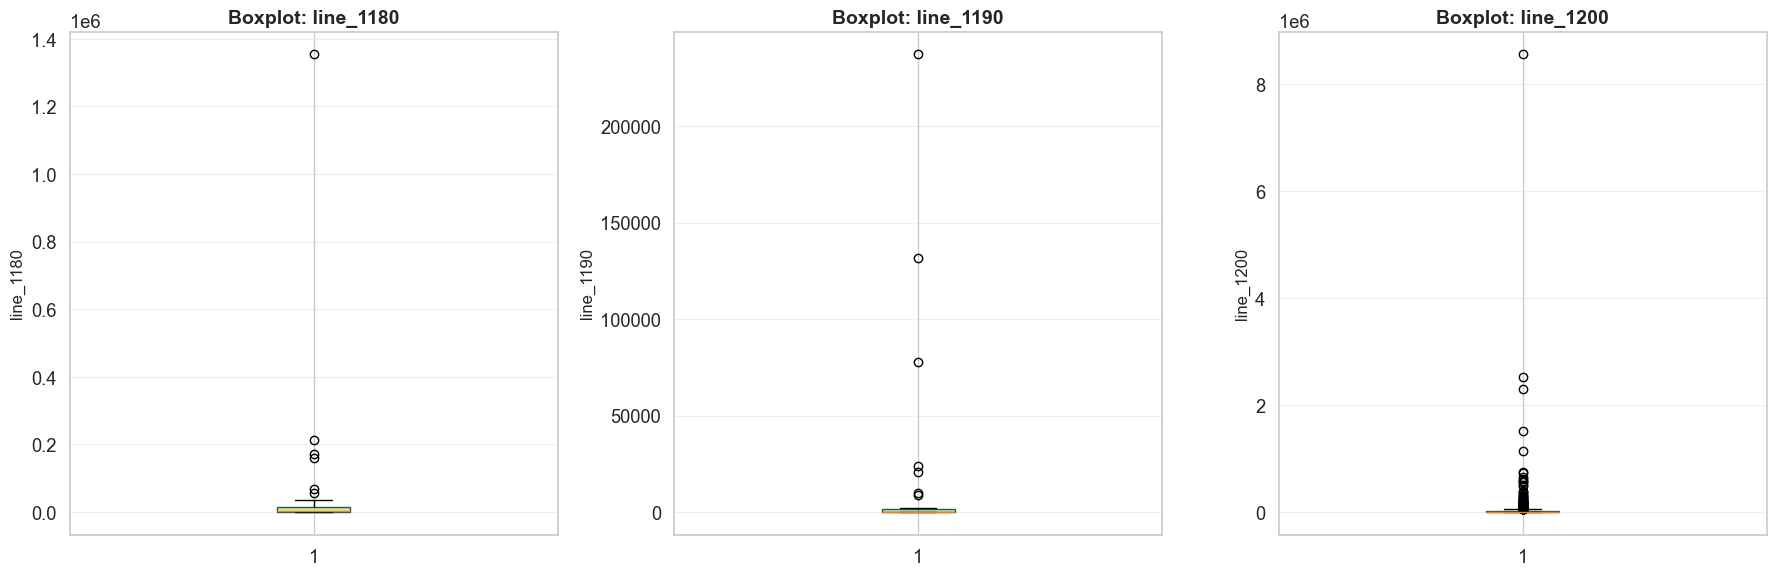

✓ Boxplot сохранен


In [27]:
# Визуализация выбросов с помощью boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, col in enumerate(columns_to_plot):
    if col in df_sample.columns:
        data = df_sample[col].dropna()
        
        bp = axes[idx].boxplot(data, vert=True, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightgreen')
        bp['boxes'][0].set_alpha(0.7)
        
        axes[idx].set_ylabel(col, fontsize=12)
        axes[idx].set_title(f'Boxplot: {col}', fontsize=14, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../visualizations/boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Boxplot сохранен")

## 9. Матрица корреляции

In [28]:
# Выбор только числовых колонок
numeric_cols = df_sample.select_dtypes(include=[np.number]).columns
df_numeric = df_sample[numeric_cols]

print(f"Числовых колонок для анализа: {len(numeric_cols)}")
print(f"Колонки: {numeric_cols.tolist()}")

Числовых колонок для анализа: 9
Колонки: ['age', 'eligible', 'financial', 'line_1180', 'line_1190', 'line_1200', 'line_1210', 'totals_adjustment', 'outlier']


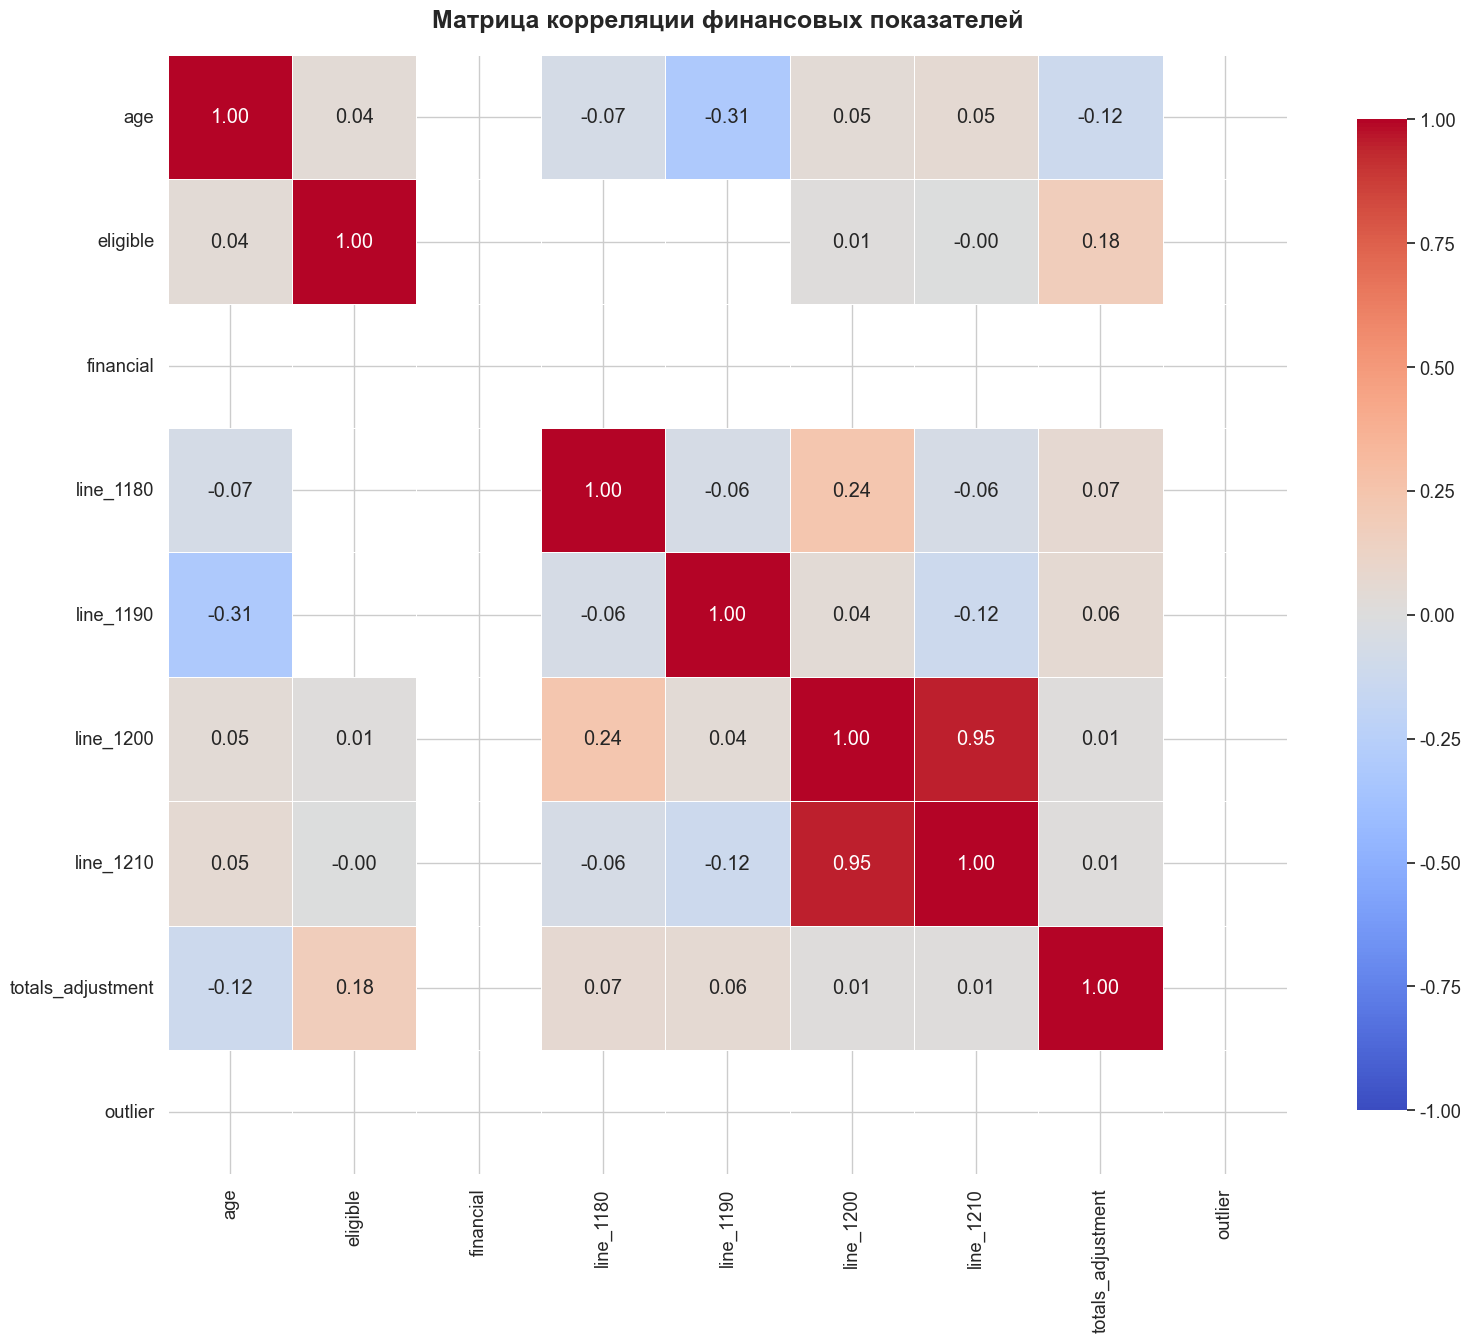

✓ Матрица корреляции построена и сохранена


In [29]:
# Вычисление матрицы корреляции
correlation_matrix = df_numeric.corr()

# # Визуализация
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Показать значения
    fmt='.2f',           # Формат чисел
    cmap='coolwarm',     # Цветовая схема
    center=0,            # Центр шкалы
    square=True,         # Квадратные ячейки
    linewidths=0.5,      # Разделительные линии
    cbar_kws={"shrink": 0.8},
    vmin=-1, vmax=1      # Диапазон значений
)
plt.title('Матрица корреляции финансовых показателей', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../visualizations/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Матрица корреляции построена и сохранена")

In [31]:
# Поиск пар с высокой корреляцией
def find_high_correlations(corr_matrix, threshold=0.7):
    """
    Находит пары переменных с корреляцией выше порогового значения
    """
    # Получаем верхний треугольник матрицы (избегаем дубликатов)
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Находим пары с корреляцией выше порога
    high_corr_pairs = []
    for column in upper_triangle.columns:
        for index in upper_triangle.index:
            value = upper_triangle.loc[index, column]
            if pd.notna(value) and abs(value) > threshold:
                high_corr_pairs.append({
                    'Переменная 1': index,
                    'Переменная 2': column,
                    'Корреляция': value
                })
    
    # Сортировка по абсолютному значению корреляции
    high_corr_df = pd.DataFrame(high_corr_pairs)
    if len(high_corr_df) > 0:
        high_corr_df['Абс. значение'] = high_corr_df['Корреляция'].abs()
        high_corr_df = high_corr_df.sort_values('Абс. значение', ascending=False)
    
    return high_corr_df

# # Поиск высоких корреляций
high_correlations = find_high_correlations(correlation_matrix, threshold=0.7)
print("\n=== ПАРЫ С ВЫСОКОЙ КОРРЕЛЯЦИЕЙ (|r| > 0.7) ===")
if len(high_correlations) > 0:
    display(high_correlations)
else:
    print("Пар с корреляцией выше 0.7 не найдено")
    # Попробуем более низкий порог
    high_correlations = find_high_correlations(correlation_matrix, threshold=0.5)
    print("\n=== ПАРЫ С КОРРЕЛЯЦИЕЙ > 0.5 ===")
    display(high_correlations.head(10))


=== ПАРЫ С ВЫСОКОЙ КОРРЕЛЯЦИЕЙ (|r| > 0.7) ===


,Переменная 1,Переменная 2,Корреляция,Абс. значение
0,line_1200,line_1210,0.95,0.95


## 10. Scatter Plots для коррелирующих переменных

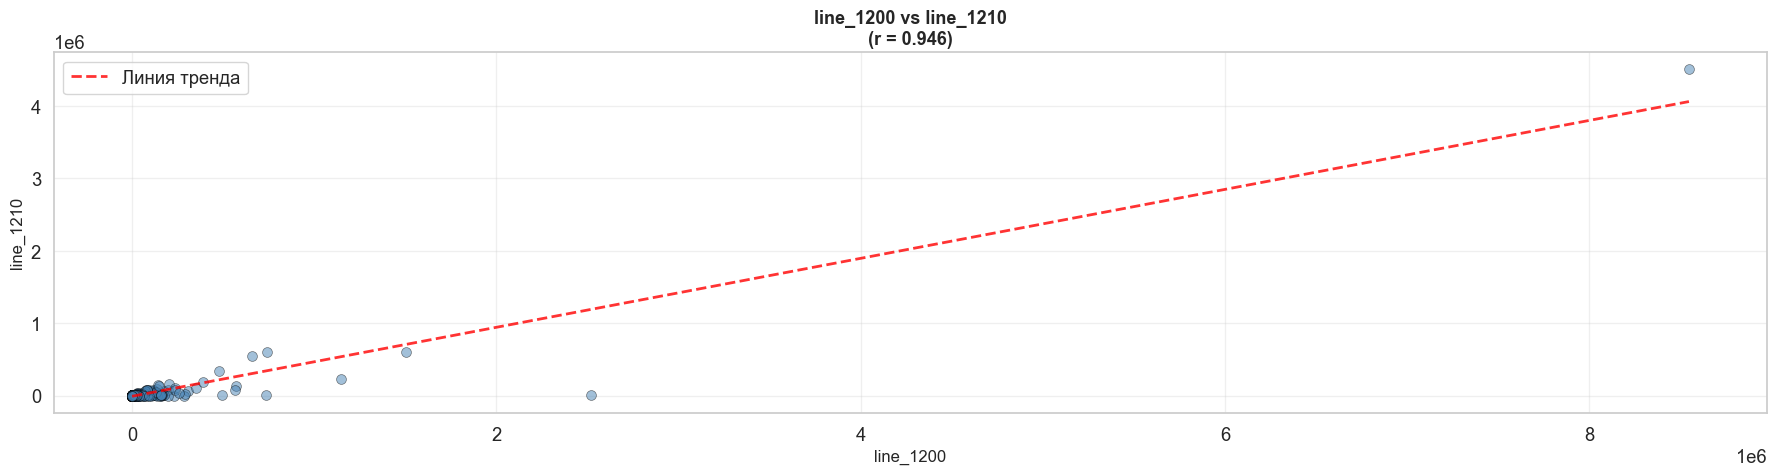

✓ Scatter plots построены и сохранены


In [32]:
# Выбираем топ-3 пары с наивысшей корреляцией
if len(high_correlations) >= 3:
    top_pairs = high_correlations.head(3)
else:
    top_pairs = high_correlations

fig, axes = plt.subplots(1, min(3, len(top_pairs)), figsize=(18, 5))
if len(top_pairs) == 1:
    axes = [axes]

for idx, (_, row) in enumerate(top_pairs.iterrows()):
    if idx >= 3:
        break
    
    var1 = row['Переменная 1']
    var2 = row['Переменная 2']
    corr_value = row['Корреляция']
    
    # Удаляем NaN значения для построения графика
    data_clean = df_sample[[var1, var2]].dropna()
    
    # Scatter plot
    axes[idx].scatter(
        data_clean[var1], 
        data_clean[var2], 
        alpha=0.5, 
        s=50,
        color='steelblue',
         edgecolors='black',
        linewidth=0.5
    )
    
    # Линия тренда
    z = np.polyfit(data_clean[var1], data_clean[var2], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(data_clean[var1].min(), data_clean[var1].max(), 100)
    axes[idx].plot(
        x_trend, 
        p(x_trend), 
        "r--", 
        alpha=0.8, 
        linewidth=2,
        label='Линия тренда'
    )
    
    axes[idx].set_xlabel(var1, fontsize=12)
    axes[idx].set_ylabel(var2, fontsize=12)
    axes[idx].set_title(f'{var1} vs {var2}\n(r = {corr_value:.3f})', fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../visualizations/scatter_plots/scatter_plots_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scatter plots построены и сохранены")

## 11. Выводы и интересные детали

### 🔍 Интересная деталь №1: [Название]

[Опишите первую находку на основе анализа]

### 🔍 Интересная деталь №2: [Название]

[Опишите вторую находку]

### 🔍 Интересная деталь №3: [Название]

[Опишите третью находку]

### 📊 Общие выводы:

1. **Описательная статистика:** [Основные выводы]
2. **Распределения:** [Что показали гистограммы]
3. **Выбросы:** [Характер и причины аномалий]
4. **Корреляции:** [Основные связи между переменными]
5. **Практические следствия:** [Что это значит для бизнеса]

## 12. Дополнительный анализ (опционально)

### Анализ по отраслям

In [ ]:
# Если есть колонка с отраслями, можно провести групповой анализ
# if 'industry' in df_sample.columns:
#     print("=== СРЕДНИЕ ПОКАЗАТЕЛИ ПО ОТРАСЛЯМ ===")
#     industry_stats = df_sample.groupby('industry')[numeric_cols].mean()
#     display(industry_stats)
#     
#     # Визуализация
#     fig, ax = plt.subplots(figsize=(12, 6))
#     industry_stats['revenue'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
#     ax.set_xlabel('Средняя выручка', fontsize=12)
#     ax.set_ylabel('Отрасль', fontsize=12)
#     ax.set_title('Средняя выручка по отраслям', fontsize=14, fontweight='bold')
#     plt.tight_layout()
#     plt.show()

### Временной анализ

In [ ]:
# Если есть колонка с годами
# if 'year' in df_sample.columns:
#     print("=== ДИНАМИКА ПОКАЗАТЕЛЕЙ ПО ГОДАМ ===")
#     yearly_stats = df_sample.groupby('year')[numeric_cols].mean()
#     display(yearly_stats)
#     
#     # График динамики
#     fig, ax = plt.subplots(figsize=(12, 6))
#     yearly_stats['revenue'].plot(kind='line', marker='o', ax=ax, linewidth=2, markersize=8)
#     ax.set_xlabel('Год', fontsize=12)
#     ax.set_ylabel('Средняя выручка', fontsize=12)
#     ax.set_title('Динамика средней выручки по годам', fontsize=14, fontweight='bold')
#     ax.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

## 📝 Итоговая сводка

Этот notebook содержит полный анализ финансовой отчётности российских компаний:

- ✅ Датасет сокращён до 1000 строк и 20 колонок
- ✅ Выполнена описательная статистика
- ✅ Построены гистограммы для 3 показателей
- ✅ Проанализированы выбросы
- ✅ Вычислена матрица корреляции
- ✅ Построены scatter plots
- ✅ Сформулировано минимум 3 интересных детали

**Автор:** [Ваше имя]  
**Дата:** [Дата]  
**Датасет:** RFSD (Russian Financial Statements Dataset)